In [2]:
import sys
sys.path.append('/data/taylor_group/Nima/ATLAS')
sys.path.append('../')

import json
import pickle
import copy 
import random 
import glob
from functools import partial
from tqdm.auto import trange
import tqdm_joblib
from joblib import Parallel, delayed

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.distributions import constraints

from jug.engine.session import TimingSession

from ATLAS.data import PTA_Data
from ATLAS.psd_functions import *
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS import parameterized
from ATLAS.signals.timing.base import build_multi_psr_timing_model, MultiPsrTimingModel
from ATLAS.signals.timing.base import setup_timing_model
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils
from ATLAS import pulsar

# import MultiHMCGibbs

from ATLAS.samplers.canetoadracing import MultiHMCGibbs, MultiHMCGibbsWithAnalytic, AnalyticRhoTransition

%load_ext autoreload
%autoreload 2

libstempo not installed. PINT or libstempo are required to use par and tim files.


In [3]:
import matplotlib.pyplot as plt
hist_settings = dict(
    bins = 'auto',
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading data

## Option 1: To test the full capability of `ATLAS`, we only need par and tim files.

### We are using the `enterprise` pulsar object. This will be replaced by an in-house object very soon.

In [4]:
from enterprise.pulsar import Pulsar

In [5]:
pnames = ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130', 'J0406+3039', 
'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0636+5128', 
'J0645+5158', 'J0709+0458', 'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001', 
'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 
'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', 'J1713+0747', 
'J1719-1438', 'J1730-2304', 
'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857', 'J1802-2124', 
'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256', 
'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603', 
'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000', 'J2229+2643', 'J2234+0611', 
'J2234+0944', 'J2302+4442', 'J2317+1439', 'J2322+2057']
len(pnames)

67

In [6]:
parfiles_ref = sorted(glob.glob('/data/taylor_group/Nima/par/*.par'))
timfiles_ref = sorted(glob.glob('/data/taylor_group/Nima/tim/*.tim'))

### Filter the par and tim files to remove "ao-only" files

In [7]:
parfiles = []
for pname in pnames:
    for p in parfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            parfiles.append(p)

timfiles = []
for pname in pnames:
    for p in timfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            timfiles.append(p)

In [8]:
assert len(parfiles) == len(pnames)

In [9]:
Npulsars = len(pnames) # how many pulsars do you want?
Npulsars

67

In [10]:
# def doit(pidx):
#     return Pulsar(parfiles[pidx], timfiles[pidx], sort=True, ephem='DE440', timing_package='PINT')
# with tqdm_joblib.tqdm_joblib(desc="PINT Loading...", total=len(parfiles)) as progress_bar:
#     psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(len(parfiles)))

# with open('../data/NG15/NG15_v1p1_final_pint_psrs_sorted.pkl', 'wb') as fout:
#     pickle.dump(psrs, fout)

In [11]:
with open('/data/taylor_group/Nima/NG15_v1p1_final_pint_psrs.pkl', 'rb') as fin:
    psrs = pickle.load(fin)
psrs = [psr for psr in psrs if psr.name != 'J1713+0747']

In [12]:
with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

In [13]:
chosen_pidx = 0 #np.argmin([len(psr.toas) for psr in psrs])
chosen_pidx 

0

In [14]:
psrs = psrs[chosen_pidx :chosen_pidx +1]

In [15]:
len(psrs)

1

In [16]:
psrs[0].name

'B1855+09'

In [17]:
timfiles[chosen_pidx :chosen_pidx +1]

['/data/taylor_group/Nima/tim/B1855+09_PINT_20220301.nb.tim']

## Option 2: If you do not want to vary the timing model params, use the pre-made 15 year pulsar objects.

In [3]:
from enterprise.pulsar import FeatherPulsar

In [4]:
feather_files = glob.glob('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/*.feather')
psrs = []
for feather_file in feather_files:
    psr = FeatherPulsar.read_feather(feather_file)
    psrs.append(psr)

with open('/data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

FeatherPulsar.read_feather: cannot find fitpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1855+09.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file /data/taylor_group/Nima/15yr_stochastic_analysis/tutorials/data/feathers/v1p1_de440_pint_bipm2019-B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /data/taylor_group/Nima/15yr_stochasti

In [5]:
psrs = psrs[0:1]

# Model Construction

## White Noise Model

In [18]:
data = PTA_Data(psrs, 
                fixed_res = False,
                marg_timing=False, 
                diag_white_cov=False,
                linear_timing = False)
raw_res = jnp.concat(data.raw_residuals)

In [19]:
wn_model = WhiteCov(data = data)

  0%|          | 0/1 [00:00<?, ?it/s]

### Initial white noise guess

In [20]:
theta0_wn = wn_model.params_dict_to_vector(noise_dict)
theta0_wn[:5]

Array([ 1.11593531,  1.00004904,  1.04311402,  1.11184323, -7.56416433],      dtype=float64)

In [21]:
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds
wn_lower_bound, wn_upper_bound

(Array([ 0.01,  0.01,  0.01,  0.01, -9.  , -9.  , -9.  , -9.  , -9.  ,
        -9.  , -9.  , -9.  ], dtype=float64),
 Array([10., 10., 10., 10., -5., -5., -5., -5., -5., -5., -5., -5.],      dtype=float64))

## Red Noise Model

In [22]:
non_gwb_nfreqs = 30
# gwb_nfreqs = 14

In [70]:
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)

# sig_dm = Red(name='dm',
#             psd_function = partial(powerlaw),
#             nfreqs=non_gwb_nfreqs,
#             lower_bound_psd = jnp.array([-18, 0.]),
#             upper_bound_psd = jnp.array([-11, 7.0]),
#             data = data,
#             use_pulsar_tspan = False)

# sig_cor = Correlated(name='cor',
#             psd_function = partial(powerlaw, gamma = 13/3),
#             orf_function = hd_orf,
#             nfreqs=gwb_nfreqs,
#             lower_bound_psd = jnp.array([-18]),
#             upper_bound_psd = jnp.array([-11]),
#             data = data)

In [71]:
# sig = SuperSignal(signal_list = [sig_unc, sig_cor, sig_dm],
#                 signal_combination_string = "ltm|cor + unc -> unc; dm",
#                 data=data,
# )
sig = SuperSignal(signal_list = [sig_unc],
                signal_combination_string = "unc -> unc",
                data=data,
)

In [72]:
x0 = sig.model.make_initial_guess(jrandom.key(12742)) #red noise model params
phi0 = sig.model.get_phi_mat_full(x0) #red noise cov matrix
phi0.shape, x0.shape

((30, 1), (2,))

### `sig.get_helpers` updates the white noise covaraince matrix

In [74]:
TNT, TNr, rNr, logdetN = sig.get_helpers(reff = raw_res, 
                                        white_noise_params = theta0_wn, 
                                        #red_noise_basis = sig.get_Fmat_concat
                                        )
helpers = (TNT, TNr, rNr, logdetN)
TNT.shape, TNr.shape, rNr.shape, logdetN.shape

((1, 60, 60), (1, 60), (), ())

## Timing Model

In [75]:
SAMPLE = psrs[0].fitpars[1:] #['F0', 'F1']
tm_model = build_multi_psr_timing_model(parfiles[chosen_pidx :chosen_pidx +1], 
                                        timfiles[chosen_pidx :chosen_pidx +1], 
                                        SAMPLE, 
                                        load_how_many_in_parallel = 1, #24,
                                        data = data)
data.add_timing_design_matrix(tm_model.Mmats)

[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns


/panfs/accrepfs.vampire/home/laaln1/pandora/lib/python3.12/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 71 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/panfs/accrepfs.vampire/home/laaln1/pandora/lib/python3.12/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'gps2utc.clk': 14 TOA(s) before clock data start (MJD 50169.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)


[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


In [76]:
z_tm = {}
for pidx in range(sig.npsrs):
    z_tm.update({f'z_{k};{pidx}': 100 * jrandom.normal(jrandom.key(random.randint(0, 16162))) for k in SAMPLE})
z_tm 

{'z_PX;0': Array(298.48551593, dtype=float64),
 'z_ELONG;0': Array(133.00425198, dtype=float64),
 'z_ELAT;0': Array(-64.32510781, dtype=float64),
 'z_PMELONG;0': Array(162.07648782, dtype=float64),
 'z_PMELAT;0': Array(173.87931172, dtype=float64),
 'z_F0;0': Array(-179.75631639, dtype=float64),
 'z_F1;0': Array(-5.54740943, dtype=float64),
 'z_DMX_0001;0': Array(1.83358618, dtype=float64),
 'z_DMX_0002;0': Array(82.97616355, dtype=float64),
 'z_DMX_0003;0': Array(-92.50793557, dtype=float64),
 'z_DMX_0004;0': Array(80.28421946, dtype=float64),
 'z_DMX_0005;0': Array(-22.02077643, dtype=float64),
 'z_DMX_0006;0': Array(50.49256877, dtype=float64),
 'z_DMX_0007;0': Array(71.37253598, dtype=float64),
 'z_DMX_0008;0': Array(-62.95860928, dtype=float64),
 'z_DMX_0009;0': Array(23.77413442, dtype=float64),
 'z_DMX_0010;0': Array(-172.91015079, dtype=float64),
 'z_DMX_0011;0': Array(82.55604667, dtype=float64),
 'z_DMX_0012;0': Array(-53.63662124, dtype=float64),
 'z_DMX_0013;0': Array(-8.00

In [77]:
z_tm_concat = jnp.array(list(z_tm.values()))
assert z_tm_concat.shape[0] == len(psrs) * len(SAMPLE)

In [78]:
tm_model.residuals(z_tm_concat),tm_model.residuals(z_tm_concat).shape

(Array([-1.19493237e+123, -1.19493237e+123, -1.19493237e+123, ...,
         1.41393536e+123,  1.41393536e+123,  1.41393536e+123],      dtype=float64),
 (7758,))

In [ ]:
# %timeit tm_model.residuals(z_tm_concat)

40.9 μs ± 2.26 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [80]:
tm_param_dim = len(z_tm_concat)
tm_param_dim 

165

# Likelihood

### Reparameterized likelihood

In [81]:
z0 = jrandom.normal(jrandom.key(108), shape = (sig.npsrs, sig.nmodes)) # re-parameterized coefficients

In [82]:
lnprob0, coeff0 = sig.lnposterior_reparam(helpers = helpers, 
                                            red_params = x0, 
                                            z = z0)
lnprob0

Array(100501.15488398, dtype=float64)

In [83]:
# %timeit sig.lnposterior_reparam(helpers = helpers,  red_params = x0, z = z0)

78.5 μs ± 158 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [84]:
def model():

    ######################################## Timing Model ########################################
    # Declare the variables in the model
    z_tm_concat = numpyro.sample('z_tm_concat', dist.Normal(0, 1000).expand([tm_param_dim]))
    stochastic_res = tm_model.residuals(z_tm_concat)

    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', dist.Uniform(wn_lower_bound, wn_upper_bound))

    # Update the white noise covaraince matrix
    helpers_now = sig.get_helpers(reff = stochastic_res, white_noise_params=theta_wn)


    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', dist.Uniform(sig.model.lower_prior_lim_all, sig.model.upper_prior_lim_all)) #PSD params
    z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))) #the reparam coefficients

    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))

    # numpyro.deterministic('coeff', coeff)

In [85]:
# def model():

#     z = numpyro.sample('z_red', dist.Normal().expand([sig.npsrs, sig.nmodes]))

#     rn_params = numpyro.sample('rn_params', dist.Uniform(sig.model.lower_prior_lim_all, 
#                                                          sig.model.upper_prior_lim_all))

#     lnpost_val, a = sig.lnposterior_reparam(helpers=helpers, red_params=rn_params, z=z)

#     # numpyro.deterministic('a', a)
#     numpyro.factor('lnpost', lnpost_val + 0.5 * jnp.sum(z**2))

In [ ]:
nuts_kernel = numpyro.infer.NUTS(model=model)
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=500,
                          num_samples=4000,
                          num_chains=1)
mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

warmup:   0%|                                                                      | 0/4500 [00:11<?, ?it/s, 1023 steps of size 6.64e-04. acc. prob=0.59]

In [57]:
samples['xs'].shape

(4000, 30)

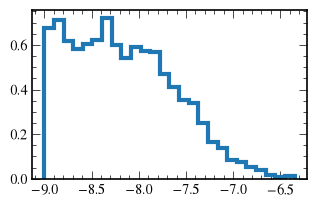

In [69]:
plt.hist(samples['xs'][:, -3], **hist_settings)
plt.show()

In [32]:
non_gwb_nfreqs

30

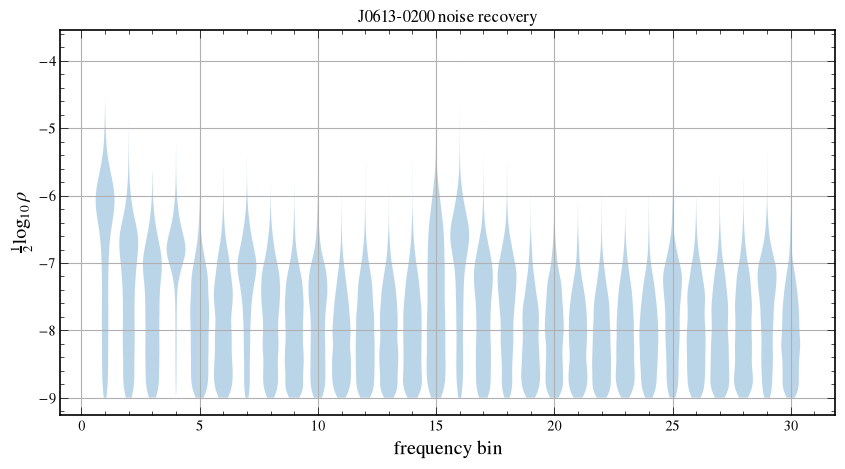

In [47]:
psr_ndx = 1
plt.figure(figsize=(10, 5))
plt.violinplot(dataset=np.array(samples['rn_params'])[:, psr_ndx * non_gwb_nfreqs : (psr_ndx + 1) * non_gwb_nfreqs],
               widths=0.8,
               showextrema=False)
plt.xlabel('frequency bin', fontsize=14)
plt.ylabel(r'$\frac{1}{2}\log_{10}\rho$', fontsize=14)
plt.title(f'{data.psr_names[psr_ndx]} noise recovery')
plt.grid()
plt.show()

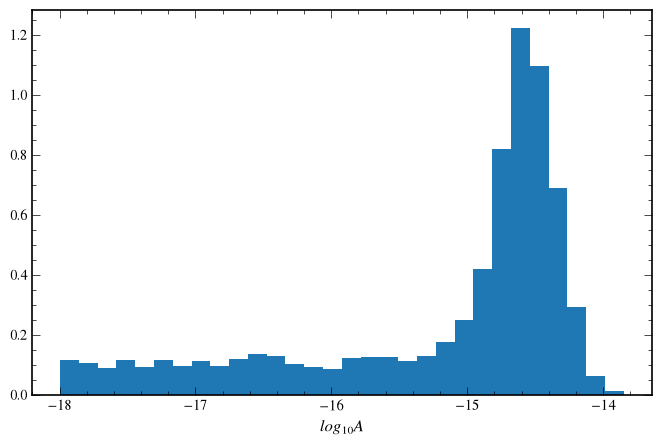

In [50]:
plt.figure(figsize=(8, 5))
plt.hist(samples['rn_params'][:, -1], density=True, bins=30)
plt.xlabel(r'$log_{10}A$')
plt.show()

In [35]:
# %timeit lnprob0, coeff0 = sig.lnposterior_reparam(helpers = (TNT, TNr), red_params = x0, z = z0)

In [31]:
from enterprise_extensions import blocks
from enterprise.signals import signal_base, gp_signals
from enterprise.pulsar import Pulsar
from astropy.time import TimeDelta
from pint.simulation import make_fake_toas_fromMJDs
import astropy.units as u
from pint.models import get_model

from enterprise_extensions import sampler
from enterprise.signals import parameter
from enterprise.signals import gp_priors

Optional mpi4py package is not installed.  MPI support is not available.


In [32]:
Tspan = gwb_Tspan

In [59]:
# # s = gp_signals.MarginalizingTimingModel(use_svd=True, normed = True)
# s = gp_signals.TimingModel(use_svd=True)
# s += blocks.white_noise_block(
#     vary=True,
#     inc_ecorr=True,
#     gp_ecorr=False,
#     select='backend',
#     tnequad=False,
# )

# # log10_A = parameter.Uniform(-18., -11.)('log10A')
# # gamma = parameter.Uniform(0., 7.)('gamma')

# # s+= gp_signals.FourierBasisGP(
# #     spectrum=gp_priors.powerlaw(log10_A=log10_A, gamma = gamma),
# #     modes = sig_unc.freqs,
# #     # components = len(sig_unc.freqs),
# #     Tspan=Tspan,
# #     name="red_noise",
# # )
# log10_rho = parameter.Uniform(-9., -2., size=len(sig_unc.freqs))
# s+= gp_signals.FourierBasisGP(
#     spectrum=gp_priors.free_spectrum(log10_rho=log10_rho),
#     components=len(sig_unc.freqs),
#     modes = sig_unc.freqs,
#     Tspan=Tspan,
#     # name="red_noise",
# )

# pta = signal_base.PTA(
#     [s(p) for p in psrs], signal_base.LogLikelihoodDenseCholesky
# )


In [ ]:
# p0 = pta.map_params(np.hstack([p.sample() for p in pta.params]))

# Timing Model

### `z_tm` is the value by which the deviations from the best fit are changed. This is an inferable parameter

In [ ]:
z_tm = {}
for pidx in range(sig.npsrs):
    z_tm.update({f'z_{k};{pidx}': 100 * jrandom.normal(jrandom.key(random.randint(0, 16162))) for k in SAMPLE})
z_tm 

In [ ]:
z_tm_concat = jnp.array(list(z_tm.values()))
assert z_tm_concat.shape[0] == len(psrs) * len(SAMPLE)

In [ ]:
tm_model.residuals(z_tm_concat),tm_model.residuals(z_tm_concat).shape

In [ ]:
# %timeit tm_model.residuals(z_tm_concat)

In [ ]:
# z_tm_concat = tm_model.get_epsilon(helpers = (MNM, MNr), key = jrandom.key(12))

In [ ]:
# tm_model.linear_residuals(z_tm_concat)

In [ ]:
tm_param_dim = len(z_tm_concat)
tm_param_dim 

# Sampling

### NOTE: Comment out the parts of the model you do not want to sample

### NOTE: If you want to fix the white noise to the NG15 noise dictionary, make sure you use the white noise dictionary to make the TNT, TNr matricies instead of prior draws.

In [ ]:
def model():

    ######################################## Timing Model ########################################
    # Declare the variables in the model
    z_tm_concat = numpyro.sample('z_tm_concat', dist.Normal(0, 100).expand([tm_param_dim]))
    stochastic_res = tm_model.residuals(z_tm_concat)
    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', dist.Uniform(ll, ul))

    # Update the white noise covaraince matrix
    TNT, TNr, rNr, logdet_N = sig.get_helpers(reff = stochastic_res, 
                                              white_noise_params=theta_wn
                                             )

    # White noise direct contribution to the PTA likelihood
    numpyro.factor('lnpost_white', -0.5 * (rNr[0] + logdet_N))

    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', dist.Uniform(o.lower_prior_lim_all, o.upper_prior_lim_all)) #PSD params
    z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))) #the reparam coefficients

    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = (TNT, TNr), red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob)

    numpyro.deterministic('coeff', coeff)

## Not Block Gibbs

In [ ]:
mcmc_bad = MCMC(
    NUTS(model),
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
    # chain_method=chain_method,
    progress_bar=True
)
mcmc_bad.run(jrandom.key(100))

In [ ]:
samples = mcmc_bad.get_samples()['xs']
samples.shape

In [ ]:
for fidx in range(30):
    plt.hist(samples[:, fidx], **hist_settings)
    plt.show()

## Block Gibbs

In [ ]:
kernel = MultiHMCGibbsWithAnalytic(
        [
        NUTS(model), 
        AnalyticRhoTransition(model = model,
                            posterior_draw_func = tm_model.get_epsilon,
                            prior_draw_func = epsilon_prior_draw
                            rho_site  = "epsilons",
                            coeff_site = "coeff",
                            rho_low  = -9.0,
                            rho_high = -2.0)
        ],
        
        [
        ['z_tm_concat', 'z_a'],
        ['xs']
        ]
    )

kernel = NUTS(model, max_tree_depth=8, target_accept_prob=0.8, dense_mass=False)

In [ ]:
mcmc_bad = MCMC(
    kernel,
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
    # chain_method=chain_method,
    progress_bar=True
)
mcmc_bad.run(jrandom.key(100))

In [ ]:
samples = mcmc_bad.get_samples()['xs']
samples.shape

In [ ]:
samples[:, -1]

In [ ]:
plt.plot(samples[:, -1])
plt.show()

# ENTERPRISE

In [ ]:
from enterprise_extensions.gibbs_sampling import gibbs

In [ ]:
m = gibbs.BayesPowerSingle(psr=psrs[0],
        Tspan=None,
        select="backend",
        white_vary=True,
        inc_ecorr=True,
        ecorr_type="kernel",
        noise_dict=noise_dict,
        tm_marg=False,
        freq_bins=30,
        tnequad=False,
        log10rhomin=-9.0,
        log10rhomax=-4.0)

In [ ]:
# good_idxs = [psrs[0].fitpars.index('F0'), psrs[0].fitpars.index('F1')] + m.gwid[0].tolist()
good_idxs = [psrs[0].fitpars.index(x) for x in SAMPLE] + m.gwid[0].tolist()
good_idxs = np.array(good_idxs)
# good_idxs = np.arange(m.Tmat.shape[-1])
good_idxs

In [ ]:
keep_idxs = np.ix_(good_idxs, good_idxs)

In [ ]:
# m = gibbs.BayesPowerSingle(psr=psrs[0],
#         Tspan=None,
#         select="backend",
#         white_vary=False,
#         inc_ecorr=True,
#         ecorr_type="kernel",
#         noise_dict=noise_dict,
#         tm_marg=False,
#         freq_bins=30,
#         tnequad=False,
#         log10rhomin=-9.0,
#         log10rhomax=-4.0,
#         keep_coeff_idxs = keep_idxs)

In [ ]:
m.sample(
        niter=int(1e4),
        wniters=30,
        eciters=10,
        savepath='/data/taylor_group/Nima/PandorasBox/Trash/GibbsTrashCan',
        SCAMweight=30,
        AMweight=15,
        DEweight=50,
        covUpdate=1000,
        burn=10000,)

In [ ]:
chain = np.load('/data/taylor_group/Nima/PandorasBox/Trash/GibbsTrashCan/chain_1.npy', mmap_mode = 'r')
chain.shape

In [ ]:
chain = chain[int(0.25 * chain.shape[0]):, :]
chain.shape

In [ ]:
for fidx in range(5):
    plt.plot(chain[:, fidx])
    plt.show()

In [ ]:
chain.shape

In [ ]:
60 + 30 +  tm_model.Mmats[0].shape[-1]

In [ ]:
for fidx in range(30):
    plt.hist(chain[:, fidx], **hist_settings, label = 'ENTERPRISE')
    # plt.hist(samples[:, fidx], **hist_settings, label = 'ATLAS')
    # plt.title(m.pta.param_names[fidx])
    plt.legend()
    plt.show()

# Flows

In [ ]:
from Atlas.flows import Flow

In [ ]:
mm = Flow(data = jnp.array(chain),
        flow_num_layers=4,
        hidden_size=128,
        mlp_num_layers=2,
        num_bins=8,
        learning_rate=1e-4,
        B=6.0,
        p=0.3,
        seed=0
         )

In [ ]:
mm.fit()

In [ ]:
gen_samps = mm.sample((int(1e4)))

In [ ]:
plt.hist(gen_samps[:, 23], **hist_settings)
plt.hist(chain[:, 23], **hist_settings)
plt.show()

In [ ]:
z = mm.backward_pass(gen_samps)
z.shape

In [ ]:
plt.hist(z[:, 23], **hist_settings)
plt.show()

In [ ]:
chain.shape[-1]

In [ ]:
from numpyro.distributions import constraints
from numpyro.distributions.constraints import Constraint
from numpyro.distributions.transforms import Transform
from jax.tree_util import register_pytree_node_class
from numpyro.infer.reparam import ExplicitReparam
from numpyro import handlers

In [ ]:
# @register_pytree_node_class
class FlowReparam(Transform):
    r"""
    """

    domain = constraints.real
    
    def __init__(
        self, flow_object
    ):
        self.flow_object = flow_object
        
    def __call__(self, x):
        return self.flow_object.forward_pass(x)

    def _inverse(self, y):
        return self.flow_object.backward_pass(y)

    def log_abs_det_jacobian(self, x, y, intermediates):
        _, total_logdet = self.flow_object.forward_pass_with_logdet(x)
        return total_logdet

    def tree_flatten(self):
        # flow_object is the dynamic part
        return ((self.flow_object,), None)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children)

In [ ]:
flow_prior = dist.TransformedDistribution(
    dist.Normal(0,1).expand([chain.shape[-1]]).to_event(1),
    FlowReparam(mm)
)

In [ ]:
def model():
    z = numpyro.sample("z", dist.Normal(0,1).expand([chain.shape[-1]]).to_event(1))
    x, total_logdet = mm.forward_pass_with_logdet(z)
    numpyro.factor('lnprob', mm.log_prob(x) + 0.5 * jnp.sum(z**2) + total_logdet)
    numpyro.deterministic('x', x)
    
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=1)
mcmc.run(jrandom.key(2))

In [ ]:
x = mcmc.get_samples()['x']
x.shape

In [ ]:
plt.hist(gen_samps[:, 23], **hist_settings)
plt.hist(x[:, 0, 23],  **hist_settings)
plt.show()

In [ ]:
from enterprise_extensions import blocks
from enterprise.signals import signal_base, gp_signals
from enterprise.pulsar import Pulsar
from astropy.time import TimeDelta
from pint.simulation import make_fake_toas_fromMJDs
import astropy.units as u
from pint.models import get_model

from enterprise_extensions import sampler
from enterprise.signals import parameter
from enterprise.signals import gp_priors

In [ ]:
s = gp_signals.TimingModel(use_svd=True)
s += blocks.white_noise_block(
    vary=True,
    inc_ecorr=True,
    gp_ecorr=False,
    select='backend',
    tnequad=False,
)

# log10_A = parameter.Uniform(-18., -11.)('log10A')
# gamma = parameter.Uniform(0., 7.)('gamma')

# s+= gp_signals.FourierBasisGP(
#     spectrum=gp_priors.powerlaw(log10_A=log10_A, gamma = gamma),
#     modes = sig_unc.freqs,
#     # components = len(sig_unc.freqs),
#     Tspan=Tspan,
#     name="red_noise",
# )
log10_rho = parameter.Uniform(-9., -2., size=len(sig_unc.freqs))
s+= gp_signals.FourierBasisGP(
    spectrum=gp_priors.free_spectrum(log10_rho=log10_rho),
    components=len(sig_unc.freqs),
    modes = sig_unc.freqs,
    Tspan=Tspan,
    # name="red_noise",
)

pta = signal_base.PTA(
    [s(p) for p in psrs], signal_base.LogLikelihoodDenseCholesky
)


In [ ]:
# pta.set_default_params(noise_dict)

In [ ]:
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

In [ ]:
# ent_samp = sampler.setup_sampler(
#     pta,
#     # x0_user = np.hstack([p.sample() for p in pta.params]),
#     outdir="/data/taylor_group/Nima/PandorasBox/Trash/TrashCan",
#     resume=False,
#     empirical_distr=None,
#     groups=None,
#     human=None,
#     save_ext_dists=False,
#     loglkwargs={},
#     logpkwargs={},
# )
# set initial parameters drawn from prior
x0 = np.hstack([p.sample() for p in pta.params])
ndim = len(x0)
cov = np.diag(np.ones(ndim) * 0.01**2)
ent_samp = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, 
                 outDir='/data/taylor_group/Nima/PandorasBox/Trash/GibbsTrashCan', resume=False)

In [ ]:
ent_samp.sample(
    p0 = np.hstack([p.sample() for p in pta.params]),
    Niter = int(2e5),
    SCAMweight=30,
    AMweight=15,
    DEweight=50,
)

In [ ]:
chain = np.loadtxt('/data/taylor_group/Nima/PandorasBox/Trash/GibbsTrashCan/chain_1.txt')
chain = chain[int(0.25 * chain.shape[0]):, :-4]
chain.shape

In [ ]:
for fidx in range(6, 36):
    plt.hist(chain[:, fidx], **hist_settings)
    plt.hist(samples[:, fidx - 6], **hist_settings)
    plt.title(pta.param_names[fidx])
    plt.show()